In [1]:
import os
import glob
import shutil
import joblib

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from astropy.io import fits
from scipy.special import expit

from tqdm import tqdm

In [2]:
models_list = glob.glob("./saved_models_selected_topk/*.joblib")
models_list

['./saved_models_selected_topk/rfi_model_HistGB_both_top3.joblib',
 './saved_models_selected_topk/rfi_model_MLP_orig_top3.joblib',
 './saved_models_selected_topk/rfi_model_HistGB_orig_top3.joblib']

In [3]:
bundle = joblib.load(models_list[1])

model_name   = bundle["model_name"]
threshold    = float(bundle["threshold"])
feature_cols = list(bundle["feature_cols"])
pipe         = bundle["pipeline"]

print("Loaded model:", model_name)
print("Threshold:", threshold)
print("Features:", feature_cols)

Loaded model: MLP_orig_top3
Threshold: 0.23
Features: ['mean_o', 'std_o', 'skew_o']


/home/user/miniconda/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.4.1.post1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/user/miniconda/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.4.1.post1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/user/miniconda/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.4.1.post1 when using version 

In [4]:
def _mean_std(x, axis):
    mean = x.mean(axis=axis)
    std  = x.std(axis=axis)
    return mean, std


def _skew_kurt_from_centered(centered, std, axis):
    m3 = (centered ** 3).mean(axis=axis)
    m4 = (centered ** 4).mean(axis=axis)

    std_safe = np.where(std == 0, 1.0, std)
    skew = m3 / (std_safe ** 3)
    kurt = m4 / (std_safe ** 4) - 3.0
    return skew, kurt


def _normalize_per_channel(seg):
    """
    seg: (H, W) = (nchan, nsamp)
    Нормализация каждой строки в диапазон [0, 256]
    """
    seg = np.asarray(seg)
    mn = seg.min(axis=1, keepdims=True)
    mx = seg.max(axis=1, keepdims=True)
    denom = mx - mn
    denom = np.where(denom == 0, 1.0, denom)
    return (seg - mn) / denom * 256.0

In [5]:
def make_fast_extractor(feature_cols):
    needed = set(feature_cols)

    allowed = {
        "mean_o","std_o","skew_o","kurt_o",
        "mean_n","std_n","skew_n","kurt_n",
        "mean_o_ratio","std_o_ratio","skew_o_ratio","kurt_o_ratio",
        "mean_n_ratio","std_n_ratio","skew_n_ratio","kurt_n_ratio",
    }
    unknown = needed - allowed
    if unknown:
        raise ValueError(f"Unknown feature names: {sorted(unknown)}")

    need_o = any(c.endswith("_o") or c.endswith("_o_ratio") for c in needed)
    need_n = any(c.endswith("_n") or c.endswith("_n_ratio") for c in needed)

    need_ratio_o = any(c.endswith("_o_ratio") for c in needed)
    need_ratio_n = any(c.endswith("_n_ratio") for c in needed)

    need_mean_o = ("mean_o" in needed) or ("mean_o_ratio" in needed)
    need_std_o  = ("std_o"  in needed) or ("std_o_ratio"  in needed)
    need_skew_o = ("skew_o" in needed) or ("skew_o_ratio" in needed)
    need_kurt_o = ("kurt_o" in needed) or ("kurt_o_ratio" in needed)

    need_mean_n = ("mean_n" in needed) or ("mean_n_ratio" in needed)
    need_std_n  = ("std_n"  in needed) or ("std_n_ratio"  in needed)
    need_skew_n = ("skew_n" in needed) or ("skew_n_ratio" in needed)
    need_kurt_n = ("kurt_n" in needed) or ("kurt_n_ratio" in needed)

    def extractor(seg):
        seg = np.asarray(seg)
        if seg.ndim != 2:
            raise ValueError(f"Expected seg with shape (H, W), got {seg.shape}")

        H, W = seg.shape
        out = {}

        if need_o:
            mean_o, std_o = _mean_std(seg, axis=1)

            if need_mean_o:
                out["mean_o"] = mean_o
            if need_std_o:
                out["std_o"] = std_o

            if need_skew_o or need_kurt_o:
                centered = seg - mean_o[:, None]
                skew_o, kurt_o = _skew_kurt_from_centered(centered, std_o, axis=1)

                if need_skew_o:
                    out["skew_o"] = skew_o
                if need_kurt_o:
                    out["kurt_o"] = kurt_o

            if need_ratio_o:
                flat = seg.reshape(-1)
                seg_mean_o, seg_std_o = _mean_std(flat, axis=0)

                seg_skew_o = seg_kurt_o = None
                if ("skew_o_ratio" in needed) or ("kurt_o_ratio" in needed):
                    centered = flat - seg_mean_o
                    seg_skew_o, seg_kurt_o = _skew_kurt_from_centered(
                        centered, np.array(seg_std_o), axis=0
                    )

                def ratio(arr, denom):
                    denom = float(denom)
                    if denom == 0:
                        return np.full(H, np.nan, dtype=float)
                    return np.asarray(arr, dtype=float) / denom

                if "mean_o_ratio" in needed:
                    out["mean_o_ratio"] = ratio(out.get("mean_o", mean_o), seg_mean_o)
                if "std_o_ratio" in needed:
                    out["std_o_ratio"]  = ratio(out.get("std_o", std_o), seg_std_o)
                if "skew_o_ratio" in needed:
                    out["skew_o_ratio"] = ratio(out.get("skew_o", skew_o), seg_skew_o)
                if "kurt_o_ratio" in needed:
                    out["kurt_o_ratio"] = ratio(out.get("kurt_o", kurt_o), seg_kurt_o)

        if need_n:
            seg_n = _normalize_per_channel(seg)

            mean_n, std_n = _mean_std(seg_n, axis=1)

            if need_mean_n:
                out["mean_n"] = mean_n
            if need_std_n:
                out["std_n"] = std_n

            if need_skew_n or need_kurt_n:
                centered = seg_n - mean_n[:, None]
                skew_n, kurt_n = _skew_kurt_from_centered(centered, std_n, axis=1)

                if need_skew_n:
                    out["skew_n"] = skew_n
                if need_kurt_n:
                    out["kurt_n"] = kurt_n

            if need_ratio_n:
                flat = seg_n.reshape(-1)
                seg_mean_n, seg_std_n = _mean_std(flat, axis=0)

                seg_skew_n = seg_kurt_n = None
                if ("skew_n_ratio" in needed) or ("kurt_n_ratio" in needed):
                    centered = flat - seg_mean_n
                    seg_skew_n, seg_kurt_n = _skew_kurt_from_centered(
                        centered, np.array(seg_std_n), axis=0
                    )

                def ratio(arr, denom):
                    denom = float(denom)
                    if denom == 0:
                        return np.full(H, np.nan, dtype=float)
                    return np.asarray(arr, dtype=float) / denom

                if "mean_n_ratio" in needed:
                    out["mean_n_ratio"] = ratio(out.get("mean_n", mean_n), seg_mean_n)
                if "std_n_ratio" in needed:
                    out["std_n_ratio"]  = ratio(out.get("std_n", std_n), seg_std_n)
                if "skew_n_ratio" in needed:
                    out["skew_n_ratio"] = ratio(out.get("skew_n", skew_n), seg_skew_n)
                if "kurt_n_ratio" in needed:
                    out["kurt_n_ratio"] = ratio(out.get("kurt_n", kurt_n), seg_kurt_n)

        df = pd.DataFrame({c: out[c] for c in feature_cols})
        return df

    return extractor

In [6]:
extract_features_from_segment = make_fast_extractor(feature_cols)
print("Feature extractor is ready for:", feature_cols)

Feature extractor is ready for: ['mean_o', 'std_o', 'skew_o']


In [7]:
def predict_mask_for_segment_sklearn(seg, pipe, threshold, extract_features_fn):
    """
    seg: (nchan, nsamp)

    Возвращает:
    - row_mask: (nchan,) bool
    - probs:    (nchan,) float
    - feats_df: (nchan, n_features) DataFrame
    """
    feats = extract_features_fn(seg)

    if hasattr(pipe, "predict_proba"):
        probs = pipe.predict_proba(feats)[:, 1]
    elif hasattr(pipe, "decision_function"):
        scores = pipe.decision_function(feats)
        probs = expit(scores)
    else:
        preds = pipe.predict(feats)
        probs = np.asarray(preds, dtype=float)

    probs = np.asarray(probs, dtype=np.float32)
    row_mask = probs >= float(threshold)

    return row_mask, probs, feats

In [8]:
def make_predict_segment_sklearn(pipe, threshold, extract_features_fn):
    """
    Возвращает функцию:
        row_mask, probs = predict_segment_fn(seg)
    """
    def predict_segment_fn(seg):
        row_mask, probs, _ = predict_mask_for_segment_sklearn(
            seg=seg,
            pipe=pipe,
            threshold=threshold,
            extract_features_fn=extract_features_fn,
        )
        return row_mask, probs

    return predict_segment_fn

In [9]:
predict_segment_fn = make_predict_segment_sklearn(
    pipe=pipe,
    threshold=threshold,
    extract_features_fn=extract_features_from_segment,
)

In [10]:
def copy_psrfits_file(src, dst=None, suffix="_masked", overwrite=False):
    src = Path(src)

    if dst is None:
        dst = src.with_name(f"{src.stem}{suffix}{src.suffix}")
    else:
        dst = Path(dst)

    if dst.exists() and not overwrite:
        raise FileExistsError(f"File already exists: {dst}")

    shutil.copy2(src, dst)
    return str(dst)

In [11]:
def get_fits_layout(fits_file, nsamp):
    with fits.open(fits_file, memmap=True) as hdul:
        data = hdul["SUBINT"].data["DATA"]   # (nsubint, nsblk, npol, nchan)
        nsubint, nsblk, npol, nchan = data.shape

    total_samples = nsubint * nsblk
    n_complete_segments = total_samples // nsamp
    tail_samples = total_samples % nsamp

    return {
        "nsubint": nsubint,
        "nsblk": nsblk,
        "npol": npol,
        "nchan": nchan,
        "total_samples": total_samples,
        "nsamp": nsamp,
        "n_complete_segments": n_complete_segments,
        "tail_samples": tail_samples,
    }

In [12]:
def read_segment_from_data_array(data_array, index, nsamp, pol=0):
    """
    data_array: hdul["SUBINT"].data["DATA"] с формой (nsubint, nsblk, npol, nchan)

    Возвращает:
    - segment_ct: (nchan, nsamp)
    - seg_info: dict для обратной записи
    """
    nsubint, nsblk, npol, nchan = data_array.shape
    total_samples = nsubint * nsblk

    if not (0 <= pol < npol):
        raise IndexError(f"pol={pol} is out of range for npol={npol}")

    position = index * nsamp
    if position + nsamp > total_samples:
        raise IndexError(
            f"Segment index={index} with nsamp={nsamp} exceeds total_samples={total_samples}"
        )

    subint_start = position // nsblk
    subint_end = (position + nsamp - 1) // nsblk + 1
    local_start = position - subint_start * nsblk

    chunk_tc = data_array[subint_start:subint_end, :, pol, :].reshape(-1, nchan).copy()
    segment_tc = chunk_tc[local_start:local_start + nsamp]
    segment_ct = segment_tc.T.copy()

    seg_info = {
        "index": index,
        "position": position,
        "nsamp": nsamp,
        "nchan": nchan,
        "subint_start": subint_start,
        "subint_end": subint_end,
        "local_start": local_start,
        "nsblk": nsblk,
        "pol": pol,
    }

    return segment_ct, seg_info

In [13]:
def write_segment_to_data_array(data_array, segment_ct, seg_info):
    """
    Записывает segment_ct формы (nchan, nsamp) обратно в data_array.
    """
    nsubint, nsblk, npol, nchan = data_array.shape

    expected_shape = (seg_info["nchan"], seg_info["nsamp"])
    if segment_ct.shape != expected_shape:
        raise ValueError(
            f"segment_ct has shape {segment_ct.shape}, expected {expected_shape}"
        )

    subint_start = seg_info["subint_start"]
    subint_end = seg_info["subint_end"]
    local_start = seg_info["local_start"]
    pol = seg_info["pol"]

    chunk_tc = data_array[subint_start:subint_end, :, pol, :].reshape(-1, nchan).copy()
    chunk_tc[local_start:local_start + seg_info["nsamp"], :] = segment_ct.T.astype(
        data_array.dtype, copy=False
    )

    data_array[subint_start:subint_end, :, pol, :] = chunk_tc.reshape(
        subint_end - subint_start,
        nsblk,
        nchan
    )

In [14]:
def get_data_any(file_or_path, index, nsamp, pol=0):
    """
    Возвращает один сегмент в форме (nchan, nsamp).
    Поддерживает путь к FITS/PSRFITS.
    """
    if isinstance(file_or_path, (str, os.PathLike)):
        path = os.fspath(file_or_path)
        if path.lower().endswith((".fits", ".sf")):
            with fits.open(path, memmap=True) as hdul:
                data_array = hdul["SUBINT"].data["DATA"]
                segment_ct, _ = read_segment_from_data_array(
                    data_array=data_array,
                    index=index,
                    nsamp=nsamp,
                    pol=pol,
                )
                return segment_ct

    raise TypeError("file_or_path must be a FITS/PSRFITS path")

In [15]:
def apply_mask_from_row_mask(data_ct, row_mask, filler="zero", random_seed=42):
    """
    data_ct:  (nchan, nsamp)
    row_mask: (nchan,) bool
    """
    data_ct = np.asarray(data_ct)
    row_mask = np.asarray(row_mask, dtype=bool)

    nchan, nsamp = data_ct.shape
    if row_mask.shape != (nchan,):
        raise ValueError(f"row_mask shape {row_mask.shape} does not match nchan={nchan}")

    data_masked = data_ct.copy()

    if filler == "zero":
        data_masked[row_mask, :] = 0

    elif filler == "noise":
        clean_rows = data_ct[~row_mask, :]

        if clean_rows.size == 0:
            mu = float(np.mean(data_ct))
            sigma = float(np.std(data_ct))
        else:
            mu = float(np.mean(clean_rows))
            sigma = float(np.std(clean_rows))

        rng = np.random.default_rng(random_seed)
        noise = rng.normal(
            loc=mu,
            scale=max(sigma, 1e-6),
            size=(int(row_mask.sum()), nsamp),
        )

        noise = np.clip(noise, data_ct.min(), data_ct.max())
        data_masked[row_mask, :] = noise.astype(data_ct.dtype, copy=False)

    else:
        raise ValueError("filler must be 'zero' or 'noise'")

    return data_masked

In [16]:
def apply_mask_to_segment(data_ct, predict_segment_fn, filler="zero", random_seed=42):
    """
    data_ct: (nchan, nsamp)

    predict_segment_fn(seg) должен вернуть:
    - row_mask: (nchan,) bool
    - probs:    (nchan,) float
    """
    row_mask, probs = predict_segment_fn(data_ct)

    row_mask = np.asarray(row_mask, dtype=bool)
    probs = np.asarray(probs, dtype=np.float32)

    nchan = data_ct.shape[0]
    if row_mask.shape != (nchan,):
        raise ValueError(f"row_mask shape {row_mask.shape} does not match nchan={nchan}")
    if probs.shape != (nchan,):
        raise ValueError(f"probs shape {probs.shape} does not match nchan={nchan}")

    data_masked = apply_mask_from_row_mask(
        data_ct=data_ct,
        row_mask=row_mask,
        filler=filler,
        random_seed=random_seed,
    )

    return data_masked, row_mask, probs

In [17]:
def plot_masked_segment(
    file_or_path,
    index,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    title="",
    plot=True,
    save_path=None,
):
    """
    Читает один сегмент, применяет маску, но не пишет в файл.

    Возвращает:
    - original_data : (nchan, nsamp)
    - masked_data   : (nchan, nsamp)
    - row_mask      : (nchan,)
    - probs         : (nchan,)
    """
    data_ct = get_data_any(file_or_path, index=index, nsamp=nsamp, pol=pol)

    data_masked_ct, row_mask, probs = apply_mask_to_segment(
        data_ct=data_ct,
        predict_segment_fn=predict_segment_fn,
        filler=filler,
        random_seed=random_seed,
    )

    if plot:
        overlay = np.repeat(row_mask[:, None], data_ct.shape[1], axis=1).astype(float)
        cmap_black = ListedColormap([(0, 0, 0, 0.0), (0, 0, 0, 1.0)])

        vmin = float(np.min(data_ct))
        vmax = float(np.max(data_ct))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
        fig.suptitle(f"Index {index} | {title}".strip(), fontsize=13)

        ax1.imshow(
            data_ct,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
            origin="upper",
        )
        ax1.set_title("Original")
        ax1.set_xlabel("Time samples")
        ax1.set_ylabel("Channel")

        ax2.imshow(
            data_masked_ct,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
            origin="upper",
        )
        ax2.imshow(
            overlay,
            cmap=cmap_black,
            vmin=0,
            vmax=1,
            aspect="auto",
            origin="upper",
        )
        ax2.set_title(f"Masked ({filler})")
        ax2.set_xlabel("Time samples")

        plt.tight_layout()

        if save_path is not None:
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, dpi=250, bbox_inches="tight")
        else:
            plt.show()

    return data_ct, data_masked_ct, row_mask, probs

In [18]:
def write_one_masked_segment_to_fits(
    fits_file,
    index,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify=True,
):
    with fits.open(fits_file, memmap=True, mode="update") as hdul:
        data_array = hdul["SUBINT"].data["DATA"]

        original_data_ct, seg_info = read_segment_from_data_array(
            data_array=data_array,
            index=index,
            nsamp=nsamp,
            pol=pol,
        )

        masked_data_ct, row_mask, probs = apply_mask_to_segment(
            data_ct=original_data_ct,
            predict_segment_fn=predict_segment_fn,
            filler=filler,
            random_seed=random_seed,
        )

        write_segment_to_data_array(data_array, masked_data_ct, seg_info)
        hdul.flush()

    if verify:
        reread_data_ct = get_data_any(fits_file, index=index, nsamp=nsamp, pol=pol)
        if not np.array_equal(masked_data_ct, reread_data_ct):
            diff = np.abs(
                masked_data_ct.astype(np.int64) - reread_data_ct.astype(np.int64)
            )
            raise RuntimeError(
                "Round-trip verification failed.\n"
                f"max|diff| = {diff.max()}, n_diff = {(diff != 0).sum()}"
            )

    return original_data_ct, masked_data_ct, row_mask, probs

In [19]:
def process_fits_segments(
    fits_file,
    indices,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify_every=None,
    desc="Applying mask",
):
    indices = list(indices)
    stats = []

    with fits.open(fits_file, memmap=True, mode="update") as hdul:
        data_array = hdul["SUBINT"].data["DATA"]
        nsubint, nsblk, npol, nchan = data_array.shape
        total_samples = nsubint * nsblk
        n_complete_segments = total_samples // nsamp

        pbar = tqdm(indices, desc=desc, unit="segment")

        for i, index in enumerate(pbar, start=1):
            if not (0 <= index < n_complete_segments):
                raise IndexError(
                    f"index={index} is out of range [0, {n_complete_segments - 1}]"
                )

            original_data_ct, seg_info = read_segment_from_data_array(
                data_array=data_array,
                index=index,
                nsamp=nsamp,
                pol=pol,
            )

            seed_i = None if random_seed is None else int(random_seed + index)

            masked_data_ct, row_mask, probs = apply_mask_to_segment(
                data_ct=original_data_ct,
                predict_segment_fn=predict_segment_fn,
                filler=filler,
                random_seed=seed_i,
            )

            write_segment_to_data_array(data_array, masked_data_ct, seg_info)

            if verify_every is not None and verify_every > 0 and (i % verify_every == 0):
                reread_data_ct, _ = read_segment_from_data_array(
                    data_array=data_array,
                    index=index,
                    nsamp=nsamp,
                    pol=pol,
                )

                if not np.array_equal(masked_data_ct, reread_data_ct):
                    diff = np.abs(
                        masked_data_ct.astype(np.int64) - reread_data_ct.astype(np.int64)
                    )
                    raise RuntimeError(
                        f"Verification failed at index={index}. "
                        f"max|diff|={diff.max()}, n_diff={(diff != 0).sum()}"
                    )

            stats.append({
                "index": int(index),
                "n_masked": int(row_mask.sum()),
                "frac_masked": float(row_mask.mean()),
                "prob_min": float(probs.min()),
                "prob_mean": float(probs.mean()),
                "prob_max": float(probs.max()),
            })

            pbar.set_postfix(masked=int(row_mask.sum()))

        hdul.flush()

    return pd.DataFrame(stats)

In [20]:
def mask_one_index_in_fits(
    fits_file,
    index,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify=True,
):
    return process_fits_segments(
        fits_file=fits_file,
        indices=[index],
        nsamp=nsamp,
        predict_segment_fn=predict_segment_fn,
        filler=filler,
        random_seed=random_seed,
        pol=pol,
        verify_every=1 if verify else None,
        desc=f"Masking index {index}",
    )

In [21]:
def mask_indices_in_fits(
    fits_file,
    indices,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify_every=None,
):
    return process_fits_segments(
        fits_file=fits_file,
        indices=indices,
        nsamp=nsamp,
        predict_segment_fn=predict_segment_fn,
        filler=filler,
        random_seed=random_seed,
        pol=pol,
        verify_every=verify_every,
        desc="Masking selected indices",
    )

In [22]:
def mask_index_range_in_fits(
    fits_file,
    index_from,
    index_to,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify_every=None,
    inclusive=True,
):
    """
    Если inclusive=True:
        обработает индексы index_from ... index_to включительно
    Если inclusive=False:
        обработает индексы index_from ... index_to-1
    """
    if index_to < index_from:
        raise ValueError("index_to must be >= index_from")

    stop = index_to + 1 if inclusive else index_to

    return process_fits_segments(
        fits_file=fits_file,
        indices=range(index_from, stop),
        nsamp=nsamp,
        predict_segment_fn=predict_segment_fn,
        filler=filler,
        random_seed=random_seed,
        pol=pol,
        verify_every=verify_every,
        desc=f"Masking range {index_from}..{index_to}",
    )

In [23]:
def mask_full_fits(
    fits_file,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify_every=None,
):
    layout = get_fits_layout(fits_file, nsamp=nsamp)
    n_complete_segments = layout["n_complete_segments"]

    if layout["tail_samples"] != 0:
        print(
            f"Warning: total_samples is not divisible by nsamp. "
            f"Tail of {layout['tail_samples']} samples will be ignored."
        )

    return process_fits_segments(
        fits_file=fits_file,
        indices=range(n_complete_segments),
        nsamp=nsamp,
        predict_segment_fn=predict_segment_fn,
        filler=filler,
        random_seed=random_seed,
        pol=pol,
        verify_every=verify_every,
        desc="Masking full file",
    )

In [24]:
def inspect_segment_sklearn(
    file_or_path,
    index,
    nsamp,
    pipe,
    threshold,
    extract_features_fn,
    pol=0,
):
    seg = get_data_any(file_or_path, index=index, nsamp=nsamp, pol=pol)
    row_mask, probs, feats = predict_mask_for_segment_sklearn(
        seg=seg,
        pipe=pipe,
        threshold=threshold,
        extract_features_fn=extract_features_fn,
    )
    return seg, row_mask, probs, feats

In [50]:
directory = '/hercules/results/akazantsev/filterbank_files/B0531+21/'
filename = 'B0531+21_59000_48386_for_rfiweather_test.fits'
#src_file = f'{directory}{filename}' # B0531+21_59000_48386

# src_file = '/hercules/results/akazantsev/filterbank_files/B0531+21/B0531+21_60482_57794.fits' # B0531+21_60482_57794
# src_file = '/hercules/results/akazantsev/filterbank_files/B0355+54_60285/B0355+54_60285.fits' # B0355+54_60285
# src_file = '/hercules/results/akazantsev/filterbank_files/B1933+16/B1933+16_59475_68410.fits'
src_file = '/hercules/results/akazantsev/filterbank_files/FRB20240114A/FRB20240114A_60384.fits'

noise_mode = ['zero', 'noise'][0]

In [51]:
work_file = copy_psrfits_file(src_file, suffix=f"_mlp_masked_{noise_mode}", overwrite=True)

print(work_file)

/hercules/results/akazantsev/filterbank_files/FRB20240114A/FRB20240114A_60384_mlp_masked_zero.fits


In [52]:
layout = get_fits_layout(work_file, nsamp=256)
pd.Series(layout)

nsubint                   16208
nsblk                      2048
npol                          4
nchan                       512
total_samples          33193984
nsamp                       256
n_complete_segments      129664
tail_samples                  0
dtype: int64

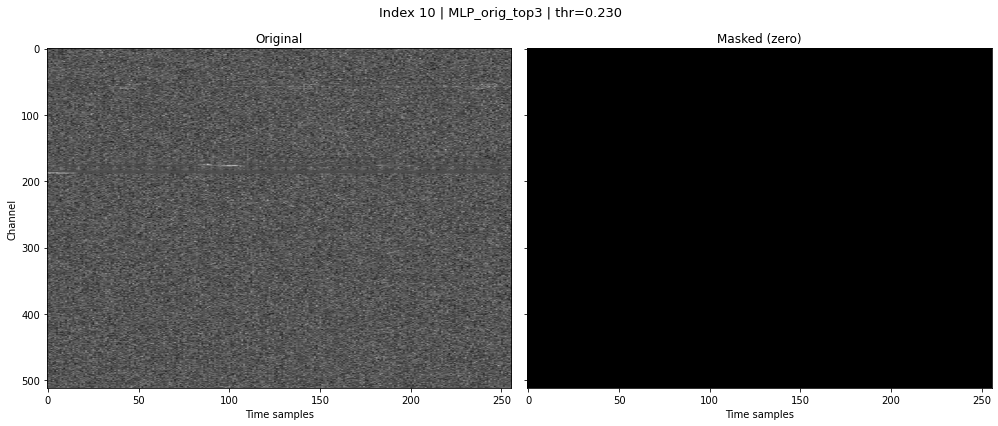

In [53]:
# Проверить один сегмент без записи

data0, masked0, row_mask0, probs0 = plot_masked_segment(
    file_or_path=work_file,
    index=10,
    nsamp=256,
    predict_segment_fn=predict_segment_fn,
    filler=noise_mode,
    plot=True,
    title=f"{model_name} | thr={threshold:.3f}",
)

In [ ]:
# Посмотреть признаки на одном сегменте

seg, row_mask, probs, feats = inspect_segment_sklearn(
    file_or_path=work_file,
    index=10,
    nsamp=256,
    pipe=pipe,
    threshold=threshold,
    extract_features_fn=extract_features_from_segment,
)

print("Masked channels:", int(row_mask.sum()), "out of", row_mask.size)
display(feats.head())

In [ ]:
# Записать один индекс и проверить round-trip

orig1, masked1, row_mask1, probs1 = write_one_masked_segment_to_fits(
    fits_file=work_file,
    index=10,
    nsamp=256,
    predict_segment_fn=predict_segment_fn,
    filler=noise_mode,
    verify=True,
)

print(np.array_equal(masked0, masked1))
print(np.array_equal(row_mask0, row_mask1))

In [ ]:
# Обработать несколько индексов

stats_some = mask_indices_in_fits(
    fits_file=work_file,
    indices=[10, 11, 12, 50, 51],
    nsamp=256,
    predict_segment_fn=predict_segment_fn,
    filler=noise_mode,
    verify_every=1,
)

stats_some

In [ ]:
# Обработать диапазон индексов

stats_range = mask_index_range_in_fits(
    fits_file=work_file,
    index_from=100,
    index_to=199,
    nsamp=256,
    predict_segment_fn=predict_segment_fn,
    filler=noise_mode,
    verify_every=10,
    inclusive=True,
)

stats_range.head()

In [54]:
# Обработать весь файл

stats_full = mask_full_fits(
    fits_file=work_file,
    nsamp=256,
    predict_segment_fn=predict_segment_fn,
    filler=noise_mode,
    verify_every=None,
)

stats_full.head()

Masking full file: 100%|██████████| 129664/129664 [1:11:35<00:00, 30.19segment/s, masked=509]  


,index,n_masked,frac_masked,prob_min,prob_mean,prob_max
0,0,512,1.000000,0.350353,0.985266,1.0
1,1,512,1.000000,0.566692,0.989174,1.0
2,2,511,0.998047,0.135338,0.972374,1.0
3,3,512,1.000000,0.515675,0.989255,1.0
4,4,512,1.000000,0.636048,0.992943,1.0


In [ ]:
stats_full.describe()

In [ ]:
stats_full.to_csv("mask_stats_full_sklearn.csv", index=False)